In [247]:
%%capture
#!pip install -r requirements.txt
#!kaggle competitions download -c traveling-santa-2018-prime-paths

In [257]:
%matplotlib inline
import pandas as pd
import numpy as np
import random
import matplotlib.pyplot as plt
import copy

In [5]:
df = pd.read_csv('cities.csv.zip', index_col='CityId')
n_cities = len(df)

In [162]:
def prime_range(lower, upper):
    primes = set([2])
    for num in range(lower,upper + 1):
        if num > 1:
            for p in primes:
                if (num % p) == 0:
                    break
            else:
                primes.add(num)
    return primes
primes = prime_range(0, n_cities)
print(len(primes))

17802


In [304]:
N=3


array([231504.54474321, 231123.90840534, 231356.98650124, ...,
       217581.47870434, 217719.05780489, 217179.8574795 ])

In [360]:
def distance(j, k):
    d = dist_cache.get((j, k), (((df.iloc[j].values - df.iloc[k].values)**2).sum())**0.5)
    dist_cache[(j, k)] = dist_cache[(k, j)] = d
    return d
    
def evaluate_route(route):
    dist_sum = 0
    for i, (j, k) in enumerate(zip(route[:-1], route[1:])):
        dist = distance(j, k)
        # Add 10% to the distance if k is not a prime        
        if i%10 == 0:
            if k not in primes:
                dist *= 1.1
        dist_sum += dist
        j = k
    return dist_sum

def plot_eval(evalution, N=5, ax=None):
    if ax == None:
        fig, ax = plt.subplots()
    moving_average = np.convolve(evaluation, np.ones((N,))/N, mode='valid')
    ax.plot(moving_average)

def plot_path(path_list, ax=None):
    df_subset = df.iloc[path_list]
    if ax == None:
        fig, ax = plt.subplots()
    df_subset.plot(kind='scatter', x='X', y='Y', ax=ax, color=range(len(path_list)))
    ax.plot(df_subset.X, df_subset.Y, alpha=0.9)

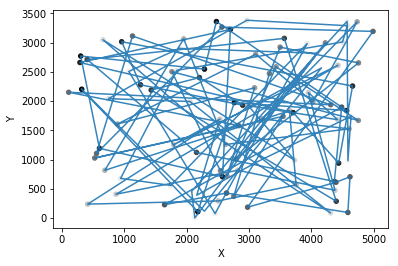

In [378]:
n_sample = 100
perm = np.random.permutation(n_cities)[:n_sample]
df_subset = df.iloc[1:].iloc[perm]
best_route = route = [0] + df_subset.index.tolist() + [0]
best_routes = [best_route]
best_route_len = route_len = evaluate_route(route)
evaluation = []
dist_cache = {}
plot_path(route)

102


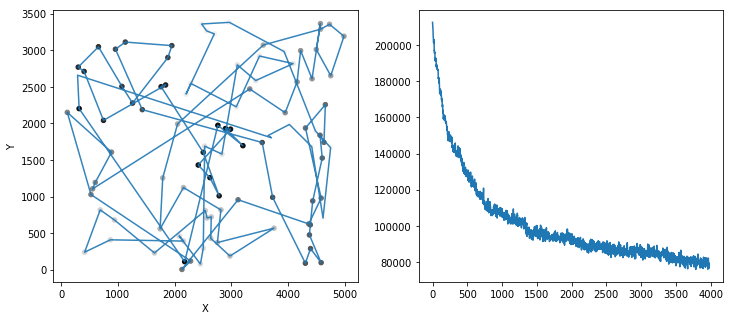

In [380]:
temp = 1.
end_temp = 0.001
cool_rate = 0.99
while temp > end_temp:
    new_route = copy.deepcopy(route)
    j, k = random.sample(range(1, n_sample - 1),2)
    new_route[k], new_route[j] = new_route[j], new_route[k]
    new_route_len = evaluate_route(new_route)
    evaluation.append(new_route_len)
    if new_route_len < best_route_len:
        p = 1.
        best_route, best_route_len = new_route, new_route_len
        best_routes.append(best_route)
    else:
        p = np.exp((route_len - new_route_len) / temp)
    if random.random() < p:
        route, route_len = new_route, new_route_len
    temp *= cool_rate

fig, axes = plt.subplots(1,2, figsize=(12,5))
print(len(route))
plot_path(route, ax=axes[0])
plot_eval(evaluation, ax=axes[1])

In [381]:
len(evaluation)

3985